# FDSI benchmark: pooled-condition GP-based BO optimisation, applied to every condition

Builds on `fdsi_09_relerror_kl_to_identity_penalty_sv1_coupling_bo` (single-condition GP-BO):
instead of tuning `lr_v`/`lr_b` on **one** reference recording, this notebook pools the search
objective across **three** contraction speeds (`triangular-ramp40s`, `triangular-ramp10s`,
`triangular-ramp5s` -- slow, mid, fast) at a single reference subject/SNR (`sub-01`, 30 dB), and
sums their `run_optimisation` losses as one Optuna objective. `triangular-ramp20s` and
`staircase` are never touched during the search -- they're held out purely to test whether the
found `(lr_v, lr_b)` generalises to conditions the optimiser never saw.

Motivation: the single-condition per-condition sweeps (`fdsi_04_optimised_per_condition-...`)
found that once the loss uses signed calibration error as an adaptive step (this config family:
`lr_alone=False`, `wh_mode='kl_to_identity'`, `max_iter_b=1`, `wh_b_coupling=True`,
`silence_penalty=True`), the optimal `(lr_v, lr_b)` cluster in a similar range across conditions
-- suggesting `lr_v`/`lr_b` act more like loss scalers than condition-specific dynamics. Pooling
the search objective across conditions is a stronger test of that than picking one condition and
hoping it transfers: the optimiser is directly rewarded for finding a setting that works
everywhere it's evaluated, not just on whichever single recording happened to be the reference.

**Config family**: error-driven natural-gradient control (`lr_alone=False`), `wh_mode='kl_to_identity'`,
`max_iter_b=1`, `wh_b_coupling=True`, `silence_penalty=True` -- identical to the base notebook.

**Not executed here** -- optimisation + full decomposition sweep (100 recordings) takes a while;
run this notebook yourself when ready. The optimiser's full trial history and the `optuna.Study`
object itself are saved to disk (§3) so the search can be inspected/re-plotted later without
re-running it.

In [ ]:
import sys
sys.path.insert(0, '../..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.calibration import calibrate_from_indices, select_units_supervised
from adapt_decomp.cbss import CBSS, CBSSConfig, CBSSResult
from adapt_decomp.config import Config, validate_literals
from adapt_decomp.optimize import optimize_adapt_decomp, DEFAULT_PARAM_SPACE
from adapt_decomp.utils import rate_of_agreement, rate_of_agreement_paired

import pickle
import optuna
import plotly.graph_objects as go

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)


In [ ]:
# ── Run control ──────────────────────────────────────────────────────────────────
# No RUN_CAL flag: calibration is always loaded from CALIBRATION_DIR (shared cache
# produced by fdsi_01_apply_best_config), never recomputed here -- see §2.
RUN_OPTIMISATION = True    # False → skip §3's GP-based BO search, reload best_config/study/
                            #   trials_per_unit_roa from OPT_DIR instead
RUN_DECOMP       = True    # False → reload cached fixed/adapted spikes from disk

FDSI_ROOT       = Path('C:/Users/Irene/Documents/work_local/muniverse/outputs/fdsi_benchmark')
CALIBRATION_DIR = Path('..', '..', 'data', 'muniverse_simulations', 'fdsi_01_max_rel_delta_kl_to_cal_no_coupling_sv_no_penalty_appliedcfg_fixed_allrec')       # shared cache (see §2)
RESULTS_DIR     = Path('..', '..', 'data', 'muniverse_simulations', 'fdsi_20_natural_gradient_kl_to_identity_coupling_sv_penalty_rel_error_bo_pooled_iterb1')
OPT_DIR         = RESULTS_DIR / 'optimisation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
OPT_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset constants ─────────────────────────────────────────────────
FS       = 2048
CAL_END  = int(5.0 * FS)   # first 5 s — stationary calibration window
ISO_DUR  = int(5.0 * FS)   # 5-s bookend for triangular phase analysis

SUBJECTS   = [f'sub-{i:02d}' for i in range(1, 6)]
CONDITIONS = ['triangular-ramp40s', 'triangular-ramp20s',
              'triangular-ramp10s', 'triangular-ramp5s', 'staircase']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]
SNR_LEVELS = [30, 25, 20, 15]
ROA_CAL_TH = 0.9

# ── CBSS calibration config ───────────────────────────────────────────────
# Must match the config that produced CALIBRATION_DIR's cache exactly (fs, ext_fact,
# sil_th, random_seed, ica_iter, search_iter) -- kept here only for parity/reference
# and because helper functions below expect CBSS_CFG.ext_fact.
CBSS_CFG = CBSSConfig(
    fs          = FS,
    ext_fact    = 10,
    sil_th      = 0.9,
    random_seed = 42,
    ica_iter    = 300,
    search_iter = 300,
    save_emg    = True,
)
# LR_V / LR_B are no longer hardcoded, and no longer come from a single reference
# recording -- they are set by the POOLED optimisation in section 3 below (search
# objective summed across POOL_CONDITIONS), then reused unchanged for every
# condition -- pooled or held out -- in section 4.
OPTIM_SUB    = 'sub-01'   # reference subject for optimisation, matches every other fdsi_0X notebook
OPTIM_SNR    = 30         # reference SNR (dB), matches every other fdsi_0X notebook

# Conditions whose losses are SUMMED into the Optuna objective -- the optimiser only
# ever sees these three. Spans slow -> fast so the found config isn't biased toward
# one end of the speed range.
POOL_CONDITIONS = ['triangular-ramp40s', 'triangular-ramp10s', 'triangular-ramp5s']
# Never touched during the search -- used only in section 4 onward to check whether
# the pooled (wh_learning_rate, sv_learning_rate) generalises to conditions the optimiser never saw.
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]

N_OPT_TRIALS = 20                  # GP-based BO trials (objective = summed loss over POOL_CONDITIONS)
LR_V, LR_B = None, None            # populated by section 3

def _to_json_safe(v):
    if isinstance(v, torch.Tensor): return v.item()
    if hasattr(v, 'item'):          return v.item()
    return v

print(f'FDSI root  : {FDSI_ROOT}')
print(f'Calibration: {CALIBRATION_DIR}  (shared cache, not recomputed)')
print(f'Results    : {RESULTS_DIR}')
print(f'Opt dir    : {OPT_DIR}')
print(f'Cal window : {CAL_END/FS:.0f} s  |  ISO bookend: {ISO_DUR/FS:.0f} s')
print(f'Recordings : {len(SUBJECTS)} subs × {len(CONDITIONS)} conds × {len(SNR_LEVELS)} SNR = '
      f'{len(SUBJECTS)*len(CONDITIONS)*len(SNR_LEVELS)}')
print(f'Opt ref    : {OPTIM_SUB}, {OPTIM_SNR} dB  |  {N_OPT_TRIALS} trials  |  sampler=GP-based BO')
print(f'Pooled     : {POOL_CONDITIONS}')
print(f'Held out   : {HOLDOUT_CONDITIONS}')

## 1. Helper functions

In [3]:
def make_adapt_config(ext_fact: int, *, adapt: bool, compute_loss: bool = True) -> Config:
    """Build an AdaptDecomp Config with default hyperparameters (no muniverse-tuned values)."""
    cfg = Config()
    cfg.ext_fact       = ext_fact
    cfg.compute_loss       = compute_loss
    cfg.device         = 'cpu'
    cfg.contrast_scope = 'spike_based'
    cfg.wh_mode        = 'kl_to_identity'
    cfg.batch_ms       = 100
    if not adapt:
        cfg.adapt_wh = False
        cfg.adapt_sv = False
        cfg.adapt_sd = False
    return cfg


def load_raw_recording(root, sub, cond, snr):
    """Load raw noisy EMG and ground-truth metadata for one FDSI recording."""
    root     = Path(root)
    emg_full = np.load(
        root / 'data' / sub / 'noisy' / f'{sub}_FDSI_{cond}_snr{snr}dB_emg.npz'
    )['emg']
    clean_dir  = root / 'data' / sub / 'clean'
    spikes_obj = np.load(clean_dir / f'{sub}_FDSI_{cond}_spikes.npz',
                         allow_pickle=True)['spikes']
    angle  = np.load(clean_dir / f'{sub}_FDSI_{cond}_angle.npz')['angle']
    effort = np.load(clean_dir / f'{sub}_FDSI_{cond}_effort.npz')['effort']
    return {'emg_full': emg_full, 'spikes_obj': spikes_obj, 'angle': angle, 'effort': effort}


def build_gt_cal_binary(spikes_obj, n_gt, n_cal):
    """Binary GT matrix for the calibration window.  Shape: (n_cal, n_gt)."""
    gt_bin = np.zeros((n_cal, n_gt), dtype=np.float32)
    for gt_idx in range(n_gt):
        idx = np.asarray(spikes_obj[gt_idx]).astype(int)
        idx = idx[(idx >= 0) & (idx < n_cal)]
        gt_bin[idx, gt_idx] = 1.0
    return gt_bin


def build_gt_full_binary_paired(spikes_obj, gt_matched_indices, n_full):
    """Binary GT matrix for the FULL recording (calibration + adaptation), ordered by CBSS unit.

    gt_matched_indices[i] → GT unit index for CBSS unit i.
    Shape: (n_full, n_kept).
    """
    n_kept = len(gt_matched_indices)
    gt_bin = np.zeros((n_full, n_kept), dtype=np.float32)
    for i, gt_idx in enumerate(gt_matched_indices):
        idx = np.asarray(spikes_obj[gt_idx]).astype(int)
        idx = idx[(idx >= 0) & (idx < n_full)]
        gt_bin[idx, i] = 1.0
    return gt_bin


def save_cbss_result(result, path):
    """Save a CBSSResult (arrays only) to a compressed npz file."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {k: v for k, v in result.to_dict().items()
            if v is not None and not isinstance(v, dict)}
    np.savez_compressed(path, **data)


def load_cbss_result(path):
    """Reconstruct a CBSSResult from a file saved by save_cbss_result."""
    _c = np.load(path, allow_pickle=False)
    return CBSSResult(
        sources        = _c['sources'],
        spikes         = _c['spikes'],
        spikes_dict    = {},
        sil            = _c['sil'],
        cov            = _c['cov'],
        sep_vectors    = _c['sep_vectors'],
        whitening      = _c['whitening'],
        extension_mean = _c['extension_mean'],
        spikes_centr   = _c['spikes_centr'],
        base_centr     = _c['base_centr'],
        emg            = _c.get('emg'),
        gt_matched_indices = _c.get('gt_matched_indices'),
        roa = _c.get('roa'),
    )


In [4]:
def get_triangular_phases(n_full):
    """Fixed 5-s phase boundaries for triangular contractions.

    First isometric folds the calibration window into the initial stationary phase.
    Returns slices into a FULL-recording array (length n_full).

      [0 ─── CAL_END ─── CAL_END+ISO_DUR ─────── n_full-ISO_DUR ─── n_full]
       |<── calibration ──>|<── first iso ──>|<── ramp ──>|<── last iso ──>|
    """
    first_iso = slice(0,                   CAL_END + ISO_DUR)
    ramp      = slice(CAL_END + ISO_DUR,   n_full  - ISO_DUR)
    last_iso  = slice(n_full  - ISO_DUR,   n_full)
    return {'first_iso': first_iso, 'ramp': ramp, 'last_iso': last_iso}


def compute_roa_subset(gt_full_bin, pred_full_spikes, s):
    """RoA for a temporal subset; s is a slice into the full-recording arrays.

    Returns per-unit RoA array; NaN if the subset is empty.
    """
    sub_gt   = gt_full_bin[s]
    sub_pred = pred_full_spikes[s]
    if sub_gt.shape[0] == 0:
        return np.full(gt_full_bin.shape[1], np.nan)
    roa, _, _ = rate_of_agreement_paired(sub_gt, sub_pred, fs=FS, tol_spike_ms=2)
    return roa


## 2. CBSS calibration — loaded from shared cache

CBSS calibration uses the identical `CBSS_CFG`/`ROA_CAL_TH` across every `fdsi_0X` notebook, so recomputing it here would just repeat work `fdsi_01_apply_best_config` already did for all 100 recordings. This notebook loads that existing cache from `CALIBRATION_DIR` instead of recomputing it.

(This loader pattern can be back-ported to `fdsi_02`–`fdsi_05`, which currently each recompute the same calibration independently, to eliminate that redundancy — not done as part of this change.)


In [5]:
calibrations = {}   # key -> calibration metadata (no large arrays stored)

pbar = tqdm(
    total=len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS),
    desc='Loading calibration (shared cache)',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key       = (sub, cond, snr)
            cache_dir = RESULTS_DIR / sub / cond   # later sections write fixed/adapted/clip caches here
            cache_dir.mkdir(parents=True, exist_ok=True)
            cal_path  = CALIBRATION_DIR / sub / cond / f'snr{snr}dB_cbss_cal.npz'

            if not cal_path.exists():
                calibrations[key] = None
                pbar.update(1)
                continue

            filtered_cal = load_cbss_result(cal_path)
            gt_matched   = filtered_cal.gt_matched_indices
            n_kept       = filtered_cal.sources.shape[1]
            # select_units_supervised computed this during matching at calibration time --
            # round-trips through save/load, no recompute needed.
            roa_kept     = filtered_cal.roa

            calibrations[key] = {
                'filtered_cal': filtered_cal,
                'gt_matched':   gt_matched,
                'n_kept':       n_kept,
                'roa_kept':     roa_kept,   # per-unit ROA of selected units
            }
            pbar.update(1)

pbar.close()
n_valid = sum(1 for v in calibrations.values() if v is not None)
print(f'Calibration loaded.  {n_valid}/{len(calibrations)} recordings with >=1 unit (ROA>{ROA_CAL_TH}).')


Loading calibration (shared cache):   0%|          | 0/100 [00:00<?, ?it/s]

Calibration loaded.  100/100 recordings with >=1 unit (ROA>0.9).


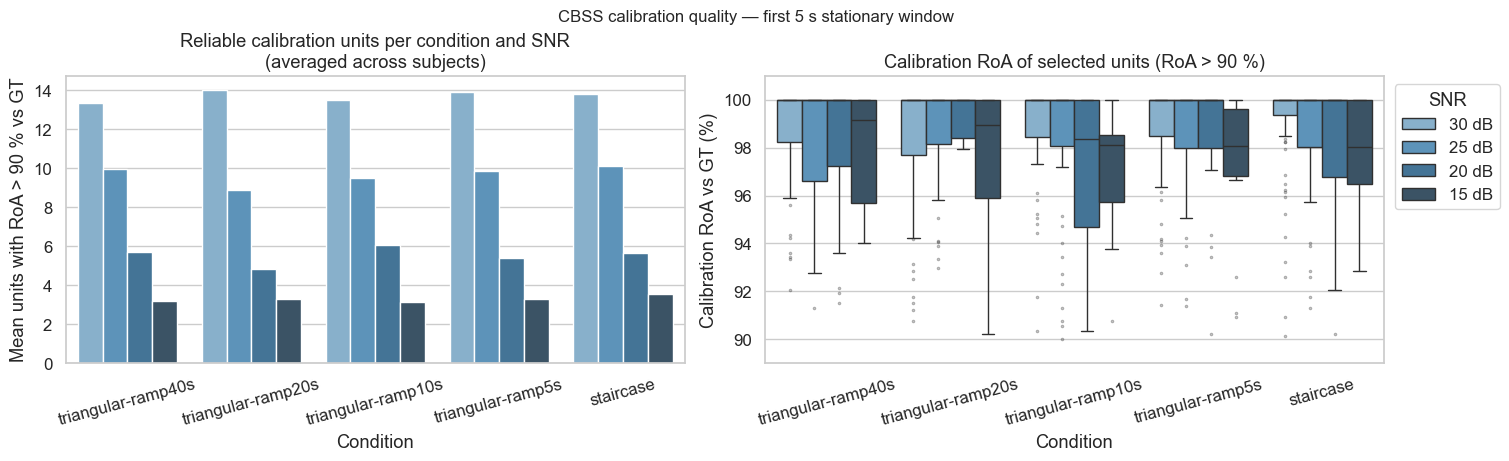

In [6]:
# ── Build calibration summary dataframe ───────────────────────────────────────
cal_rows = []
for (sub, cond, snr), cal in calibrations.items():
    if cal is None:
        continue
    for roa_val in cal['roa_kept']:
        cal_rows.append({
            'sub':       sub,
            'condition': cond,
            'snr':       snr,
            'n_kept':    cal['n_kept'],
            'roa_cal':   float(roa_val) * 100,
        })

df_cal = pd.DataFrame(cal_rows)

snr_order = [f'{s} dB' for s in SNR_LEVELS]
df_cal['SNR'] = df_cal['snr'].astype(str) + ' dB'

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(1, 2, figsize=(15, 4.5), layout='constrained')

# Left: mean number of reliably detected units per condition × SNR
n_units_mean = (
    df_cal.groupby(['condition', 'SNR'])['n_kept']
    .mean().reset_index()
)
sns.barplot(
    data=n_units_mean, x='condition', y='n_kept', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d', ax=axs[0], legend=False
)
axs[0].set(
    ylabel=f'Mean units with RoA > {int(ROA_CAL_TH*100)} % vs GT',
    xlabel='Condition',
    title='Reliable calibration units per condition and SNR\n(averaged across subjects)',
)
axs[0].tick_params(axis='x', rotation=15)

# Right: distribution of calibration RoA for selected units
sns.boxplot(
    data=df_cal, x='condition', y='roa_cal', hue='SNR',
    hue_order=snr_order, order=CONDITIONS,
    palette='Blues_d',
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    ax=axs[1],
)
axs[1].set(
    ylabel='Calibration RoA vs GT (%)',
    xlabel='Condition',
    title=f'Calibration RoA of selected units (RoA > {int(ROA_CAL_TH*100)} %)',
    ylim=(ROA_CAL_TH * 100 - 1, 101),
)
axs[1].tick_params(axis='x', rotation=15)
axs[1].legend(title='SNR', loc='upper right', bbox_to_anchor=(1.2, 1.0))

plt.suptitle('CBSS calibration quality — first 5 s stationary window', fontsize=12)
plt.show()


## 3. Hyperparameter optimisation (GP-based BO) -- pooled across POOL_CONDITIONS, with RoA logged per trial and per condition

Optimises `lr_v`/`lr_b` on **three** recordings at once (`OPTIM_SUB`, `OPTIM_SNR`, one per
condition in `POOL_CONDITIONS`) -- a single Optuna trial applies the same `(lr_v, lr_b)` to all
three, and the objective is the SUM of their `run_optimisation` losses. This directly rewards a
setting that works across conditions, rather than transferring a single-condition optimum and
hoping it generalises. `HOLDOUT_CONDITIONS` are never evaluated here -- they only reappear in
§4, applied with the pooled winner unchanged, as the actual generalisation check.

Same `sampler=GPSampler` and narrowed `lr_b` bound as the base (single-condition) notebook.
Everything else about the config (`wh_mode`, `max_iter_b`, `wh_b_coupling`, `silence_penalty`,
`lr_alone`) is fixed to match this notebook's family.

Bypasses the `optimize_adapt_decomp`/`optimize_adapt_decomp_pooled` convenience wrappers (which
only return the surrogate loss) and instead builds one `AdaptDecomp` instance per pooled
condition directly, so each trial's actual predicted spikes (`adapter.spikes`) can be paired
against that condition's **calibration-matched ground-truth units** to compute a real RoA per
trial per condition, alongside the surrogate loss actually being summed and optimised. Logged via
`trial.set_user_attr(...)`, so `study.trials_dataframe()` and the saved `trials.csv` carry
`user_attrs_loss_<condition>` / `user_attrs_roa_mean_<condition>` / `user_attrs_roa_mean_pooled`
for every trial.

Saved to `OPT_DIR` for later inspection without re-running:
- `best_config.json` -- the winning `(lr_v, lr_b)` plus every fixed flag
- `trials.csv` -- full trial history: `(lr_v, lr_b, pooled loss, per-condition loss/RoA)`
- `trials_per_unit_roa.csv` -- long-format per-unit RoA, one row per `(trial, condition, unit)`
- `study.pkl` -- the full `optuna.Study` object (pickled), including all `user_attrs`

In [ ]:
def _t(arr):
    return torch.tensor(np.asarray(arr), dtype=torch.float32)


# Reduced search space (suggested after the fdsi_09/coupling/sv5 ablations): every catastrophic
# collapse found there had sv_learning_rate tuned above ~0.02-0.045, close to the old (1e-4, 1e-1) upper bound.
# Narrowing sv_learning_rate to (1e-4, 1e-2) removes the region the optimiser kept finding trouble in.
OPT_PARAM_SPACE = {
    'wh_learning_rate': ('log_float', 1e-4, 5e-2),
    'sv_learning_rate': ('log_float', 1e-4, 1e-1),
}

OPT_BASE_CONFIG = {
    'wh_mode':         'kl_to_identity',
    'contrast_scope':  'spike_based',
    'wh_b_coupling':   True,
    'sv_epochs':      1,
    'compute_loss':        True,
    'device':          'cpu',
    'trace_check':     True,
    'optim_loss':      'single_obj',
    'silence_penalty': True,
    'lr_alone':        False,
}

sampler_name = 'GP-based BO'

if RUN_OPTIMISATION:
    # Build one AdaptDecomp adapter per pooled condition, reused across every trial -- same
    # reuse-across-trials pattern the single-condition version used, just one adapter per condition
    # instead of one overall.
    pooled = {}
    for cond in POOL_CONDITIONS:
        key = (OPTIM_SUB, cond, OPTIM_SNR)
        cal = calibrations.get(key)
        if cal is None:
            raise RuntimeError(f'No calibration available for {key} -- pick a different POOL_CONDITIONS entry.')

        raw    = load_raw_recording(FDSI_ROOT, OPTIM_SUB, cond, OPTIM_SNR)
        filt   = cal['filtered_cal']
        n_full = raw['emg_full'].shape[0]

        # Ground truth for this recording, using the SAME unit pairing calibration already
        # established (select_units_supervised, at calibration time) -- never re-matched per trial.
        gt_full_bin = build_gt_full_binary_paired(raw['spikes_obj'], cal['gt_matched'], n_full)

        run_config = Config()
        for k, v in OPT_BASE_CONFIG.items():
            setattr(run_config, k, v)
        validate_literals(run_config)

        adapter = AdaptDecomp(
            emg             = _t(raw['emg_full']),
            whitening       = _t(filt.whitening),
            sep_vectors     = _t(filt.sep_vectors).T.contiguous(),  # [dim,n_mu] -> [n_mu,dim]
            base_centr  = _t(filt.base_centr),
            spikes_centr = _t(filt.spikes_centr),
            emg_calib       = _t(filt.emg),
            ipts_calib      = _t(filt.sources),
            spikes_calib    = _t(filt.spikes),
            preprocess      = True,
            config          = run_config,
        )
        pooled[cond] = {'adapter': adapter, 'gt_full_bin': gt_full_bin}


    def objective(trial):
        wh_learning_rate = trial.suggest_float('wh_learning_rate', OPT_PARAM_SPACE['wh_learning_rate'][1], OPT_PARAM_SPACE['wh_learning_rate'][2], log=True)
        sv_learning_rate = trial.suggest_float('sv_learning_rate', OPT_PARAM_SPACE['sv_learning_rate'][1], OPT_PARAM_SPACE['sv_learning_rate'][2], log=True)

        per_cond_loss, per_cond_roa_mean = {}, {}
        for cond, bundle in pooled.items():
            adapter = bundle['adapter']
            loss = adapter.run_optimisation(wh_lr=wh_learning_rate, sv_lr=sv_learning_rate)

            pred_spikes = adapter.spikes.detach().cpu().numpy().astype(np.float32)
            roa_vals, _, _ = rate_of_agreement_paired(bundle['gt_full_bin'], pred_spikes, fs=FS, tol_spike_ms=2)

            per_cond_loss[cond]     = loss
            per_cond_roa_mean[cond] = float(np.nanmean(roa_vals)) * 100
            trial.set_user_attr(f'loss_{cond}', loss)
            trial.set_user_attr(f'roa_mean_{cond}', per_cond_roa_mean[cond])
            trial.set_user_attr(f'roa_per_unit_{cond}', [float(x) for x in roa_vals])

        trial.set_user_attr('roa_mean_pooled', float(np.mean(list(per_cond_roa_mean.values()))))
        # Pooled objective: SUM, not mean, across POOL_CONDITIONS. The divergence guard
        # (trace_check in run_optimisation) already returns 1e10 for a diverged recording, so a
        # setting that blows up on even one pooled condition dominates the sum and is rejected --
        # summing (vs. averaging, which shares the same argmin up to a constant factor) makes that
        # penalty explicit rather than incidental.
        return sum(per_cond_loss.values())


    sampler = optuna.samplers.GPSampler(n_startup_trials=15, seed=42)

    study = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(objective, n_trials=N_OPT_TRIALS)

    best_config = {**OPT_BASE_CONFIG, **study.best_params, 'optim_loss': 'single_obj'}
    LR_V, LR_B = best_config['wh_learning_rate'], best_config['sv_learning_rate']

    with open(OPT_DIR / 'best_config.json', 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config.items()}, f, indent=2)

    study.trials_dataframe().to_csv(OPT_DIR / 'trials.csv', index=False)

    # Tidy long-format per-unit table: one row per (trial, condition, unit) -- what population plots
    # (boxplot/violin of per-unit RoA, sliced by trial, by condition, by sv_learning_rate bucket, best-vs-worst,
    # ...) should be built from, rather than parsing per-condition stringified lists buried in
    # trials.csv cells.
    per_unit_rows = []
    for t in study.trials:
        if t.state != optuna.trial.TrialState.COMPLETE:
            continue
        for cond in POOL_CONDITIONS:
            for unit_idx, roa_u in enumerate(t.user_attrs[f'roa_per_unit_{cond}']):
                per_unit_rows.append({
                    'trial':     t.number,
                    'wh_learning_rate':      t.params['wh_learning_rate'],
                    'sv_learning_rate':      t.params['sv_learning_rate'],
                    'condition': cond,
                    'loss':      t.value,
                    'unit':      unit_idx,
                    'roa':       roa_u,
                })
    per_unit_df = pd.DataFrame(per_unit_rows)
    per_unit_df.to_csv(OPT_DIR / 'trials_per_unit_roa.csv', index=False)

    with open(OPT_DIR / 'study.pkl', 'wb') as f:
        pickle.dump(study, f)

    print(f'Saved best_config.json, trials.csv, trials_per_unit_roa.csv, study.pkl -> {OPT_DIR}')

else:
    # Skip re-running Optuna entirely -- reload everything the landscape/diagnostic plots below
    # need from what a prior RUN_OPTIMISATION=True pass already saved to OPT_DIR.
    with open(OPT_DIR / 'best_config.json') as f:
        best_config = json.load(f)
    LR_V, LR_B = best_config['wh_learning_rate'], best_config['sv_learning_rate']

    with open(OPT_DIR / 'study.pkl', 'rb') as f:
        study = pickle.load(f)

    per_unit_df = pd.read_csv(OPT_DIR / 'trials_per_unit_roa.csv')

    print(f'RUN_OPTIMISATION=False -- reloaded search results from {OPT_DIR}')

print(f'Best config, pooled across {POOL_CONDITIONS} (via {sampler_name}):')
print(f'  wh_learning_rate = {LR_V:.6g}')
print(f'  sv_learning_rate = {LR_B:.6g}')
print(f'  pooled objective value (summed loss) : {study.best_value:.4f}')
print(f'  pooled mean RoA                      : {study.best_trial.user_attrs["roa_mean_pooled"]:.1f}%')
for cond in POOL_CONDITIONS:
    print(f'    {cond:22s} loss={study.best_trial.user_attrs[f"loss_{cond}"]:.4f}  '
          f'RoA={study.best_trial.user_attrs[f"roa_mean_{cond}"]:.1f}%')

### Optimisation landscape: loss vs RoA

Same trials, three views: colored by the surrogate objective (what the optimiser actually
minimises), colored by the real mean RoA against ground truth, and a direct scatter of loss vs RoA
to check whether one predicts the other. If the surrogate loss is a good proxy for real
decomposition quality on this recording, low-loss points (dark, left panel) should line up with
high-RoA points (bright, middle panel) at the same `(lr_v, lr_b)` locations, and the right panel
should show a clear downward trend -- exactly the check that would have flagged the earlier
`sv5`/`ramp20s` collapse (low loss, ~1% RoA) as a mismatch rather than a good trial.

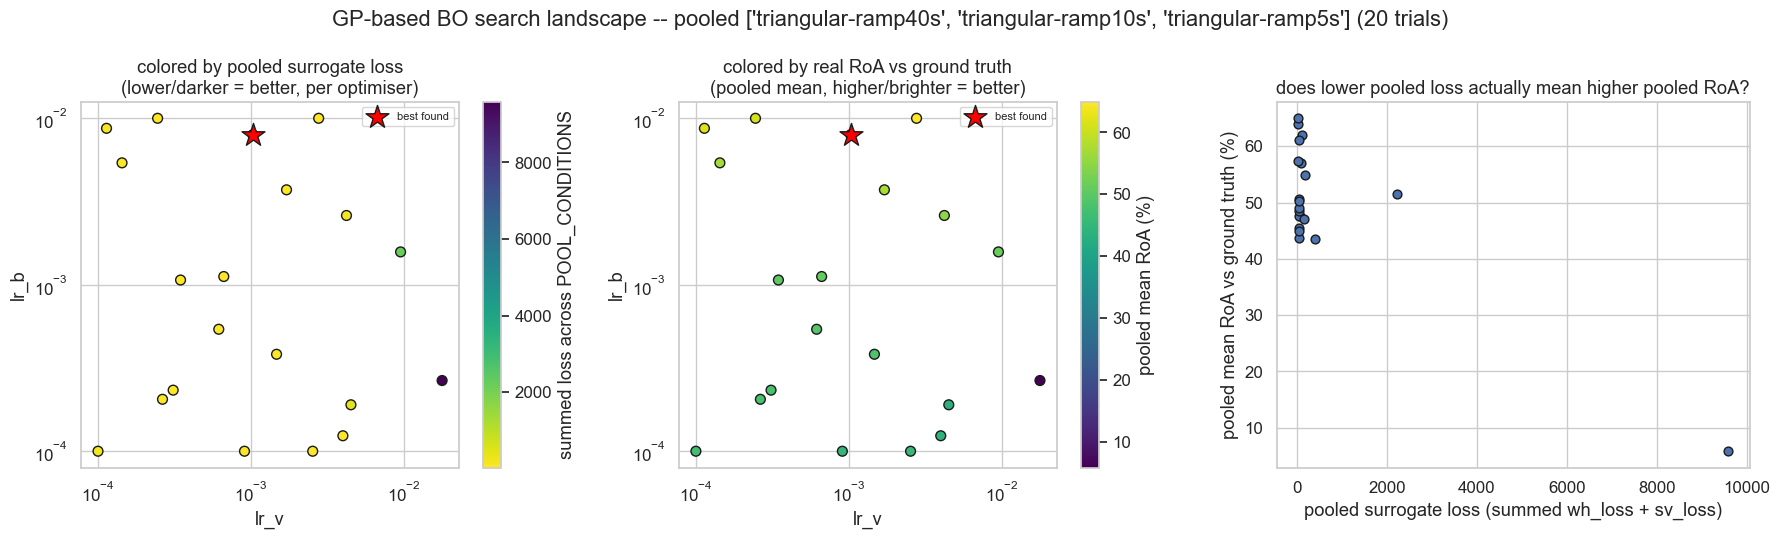

In [8]:
trials_df = study.trials_dataframe()
trials_df = trials_df[trials_df['state'] == 'COMPLETE']

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

sc0 = axes[0].scatter(trials_df['params_lr_v'], trials_df['params_lr_b'],
                        c=trials_df['value'], cmap='viridis_r', s=50, edgecolor='k')
axes[0].set_title('colored by pooled surrogate loss\n(lower/darker = better, per optimiser)')
fig.colorbar(sc0, ax=axes[0], label='summed loss across POOL_CONDITIONS')

sc1 = axes[1].scatter(trials_df['params_lr_v'], trials_df['params_lr_b'],
                        c=trials_df['user_attrs_roa_mean_pooled'], cmap='viridis', s=50, edgecolor='k')
axes[1].set_title('colored by real RoA vs ground truth\n(pooled mean, higher/brighter = better)')
fig.colorbar(sc1, ax=axes[1], label='pooled mean RoA (%)')

for ax in axes[:2]:
    ax.scatter([LR_V], [LR_B], marker='*', s=300, color='red', edgecolor='k', zorder=5, label='best found')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('wh_learning_rate')
    ax.set_ylabel('sv_learning_rate')
    ax.legend(fontsize=8)

axes[2].scatter(trials_df['value'], trials_df['user_attrs_roa_mean_pooled'], edgecolor='k', s=40)
axes[2].set_xlabel('pooled surrogate loss (summed wh_loss + sv_loss)')
axes[2].set_ylabel('pooled mean RoA vs ground truth (%)')
axes[2].set_title('does lower pooled loss actually mean higher pooled RoA?')

fig.suptitle(f'GP-based BO search landscape -- pooled {POOL_CONDITIONS} ({N_OPT_TRIALS} trials)')
plt.tight_layout()
plt.show()

### Per-condition landscape: does the good region overlap across conditions?

The pooled view above averages away exactly the thing this experiment is meant to check: whether
the good `(lr_v, lr_b)` region is the *same* region for every pooled condition, or whether the
optimiser is finding a compromise between conditions that individually disagree. One panel per
`POOL_CONDITIONS` entry, each colored by *that condition's own* RoA -- if the bright region lands
in roughly the same place in every panel, that's direct evidence for the "similar learning-rate
scale across conditions" hypothesis; if it shifts around, pooling is averaging over real
disagreement rather than confirming a shared optimum.

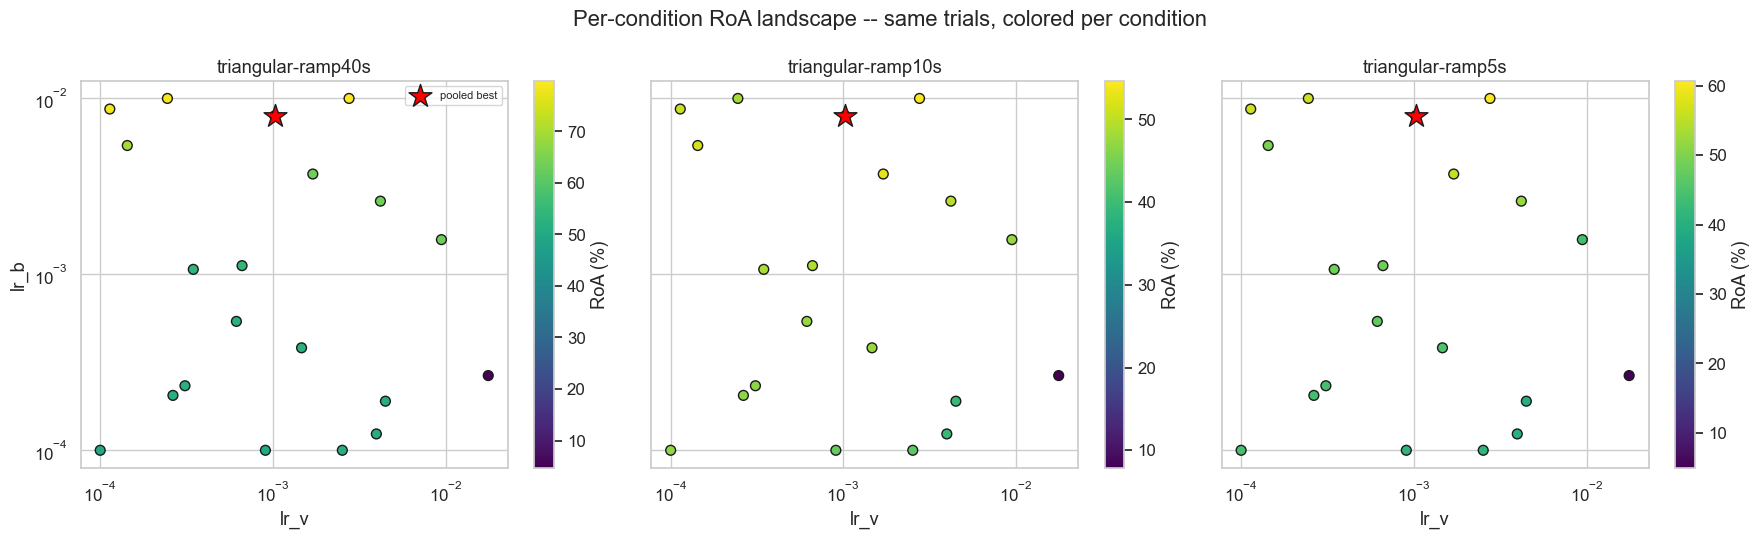

In [9]:
fig, axes = plt.subplots(1, len(POOL_CONDITIONS), figsize=(6 * len(POOL_CONDITIONS), 5.5),
                          sharex=True, sharey=True)

for ax, cond in zip(axes, POOL_CONDITIONS):
    sc = ax.scatter(trials_df['params_lr_v'], trials_df['params_lr_b'],
                     c=trials_df[f'user_attrs_roa_mean_{cond}'], cmap='viridis', s=50, edgecolor='k')
    ax.scatter([LR_V], [LR_B], marker='*', s=300, color='red', edgecolor='k', zorder=5, label='pooled best')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('wh_learning_rate')
    ax.set_title(cond)
    fig.colorbar(sc, ax=ax, label='RoA (%)')

axes[0].set_ylabel('sv_learning_rate')
axes[0].legend(fontsize=8)
fig.suptitle('Per-condition RoA landscape -- same trials, colored per condition')
plt.tight_layout()
plt.show()

### Per-unit RoA population: best vs worst trials

Mean/median hide whether a bad trial fails *uniformly* (every unit a bit worse) or *catastrophically
for a subset* (a few units collapse to ~0% while the rest are fine, dragging the mean down) -- exactly
the distinction that mattered for the `sv5`/`ramp20s` collapse found earlier. This compares the
per-unit RoA distribution for the 5 lowest-pooled-loss and 5 highest-pooled-loss trials, pooling
units across all of `POOL_CONDITIONS` together (each trial's population is now every unit from
every pooled condition, not just one recording).

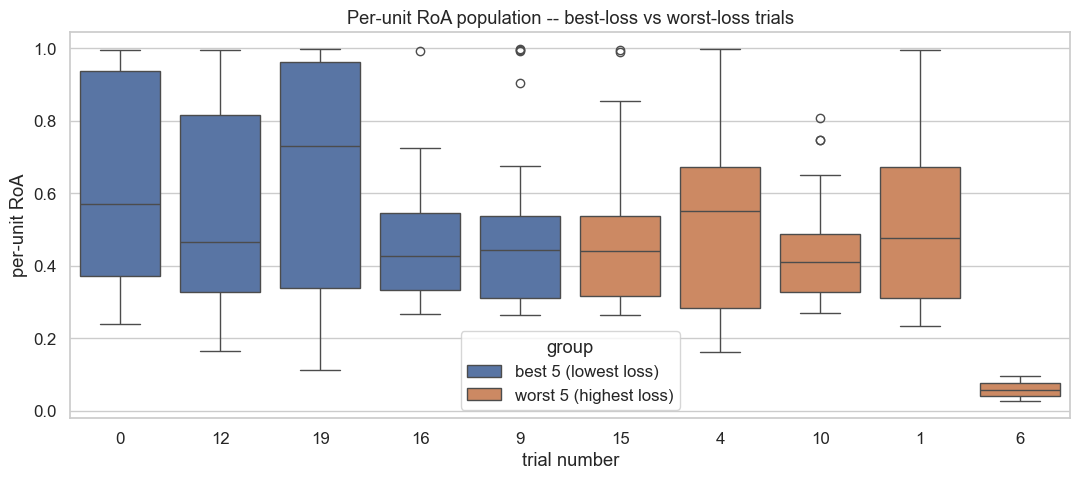

In [10]:
ranked_trials = (per_unit_df[['trial', 'loss']].drop_duplicates()
                                                .sort_values('loss'))
best_trials  = ranked_trials['trial'].head(5).tolist()
worst_trials = ranked_trials['trial'].tail(5).tolist()

plot_df = per_unit_df[per_unit_df['trial'].isin(best_trials + worst_trials)].copy()
plot_df['group'] = np.where(plot_df['trial'].isin(best_trials), 'best 5 (lowest loss)', 'worst 5 (highest loss)')
plot_df['trial'] = pd.Categorical(plot_df['trial'], categories=best_trials + worst_trials, ordered=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_df, x='trial', y='roa', hue='group', dodge=False, ax=ax,
            palette={'best 5 (lowest loss)': '#4C72B0', 'worst 5 (highest loss)': '#DD8452'})
ax.set_xlabel('trial number')
ax.set_ylabel('per-unit RoA')
ax.set_title('Per-unit RoA population -- best-loss vs worst-loss trials')
plt.tight_layout()
plt.show()

### Interactive 3D landscape: lr_v, lr_b, pooled RoA -- rotatable, color = pooled loss

Three spatial axes (`lr_v`, `lr_b`, pooled mean RoA across `POOL_CONDITIONS`) plus the pooled
surrogate loss as marker color. Two points are called out explicitly:
- **red diamond** -- the config the optimiser actually chose (lowest summed `GP-based BO` loss)
- **gold diamond** -- the config that happens to have the *highest observed pooled RoA*, regardless of loss

If these two diamonds sit far apart, that's the proxy-objective mismatch made visible in one plot:
the optimiser's surrogate and the real decomposition quality disagree about which `(lr_v, lr_b)` is
best, pooled across conditions. Drag to rotate, scroll to zoom, hover a point for its exact
trial/loss/RoA.

In [11]:
trials_df3d = study.trials_dataframe()
trials_df3d = trials_df3d[trials_df3d['state'] == 'COMPLETE']

best_roa_row = trials_df3d.loc[trials_df3d['user_attrs_roa_mean_pooled'].idxmax()]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=trials_df3d['params_lr_v'], y=trials_df3d['params_lr_b'], z=trials_df3d['user_attrs_roa_mean_pooled'],
    mode='markers',
    marker=dict(size=5, color=trials_df3d['value'], colorscale='Viridis_r',
                colorbar=dict(title='pooled loss'), showscale=True),
    text=[f'trial {t}<br>wh_learning_rate={v:.4g}<br>sv_learning_rate={b:.4g}<br>loss={l:.3f}<br>pooled RoA={r:.1f}%'
          for t, v, b, l, r in zip(trials_df3d['number'], trials_df3d['params_lr_v'],
                                    trials_df3d['params_lr_b'], trials_df3d['value'],
                                    trials_df3d['user_attrs_roa_mean_pooled'])],
    hoverinfo='text',
    name='trials',
))

fig.add_trace(go.Scatter3d(
    x=[LR_V], y=[LR_B], z=[study.best_trial.user_attrs['roa_mean_pooled']],
    mode='markers',
    marker=dict(size=10, color='red', symbol='diamond', line=dict(width=1, color='black')),
    text=[f'optimal (lowest pooled loss)<br>wh_learning_rate={LR_V:.4g}<br>sv_learning_rate={LR_B:.4g}'],
    hoverinfo='text',
    name='optimal (lowest pooled loss)',
))

fig.add_trace(go.Scatter3d(
    x=[best_roa_row['params_lr_v']], y=[best_roa_row['params_lr_b']], z=[best_roa_row['user_attrs_roa_mean_pooled']],
    mode='markers',
    marker=dict(size=10, color='gold', symbol='diamond', line=dict(width=1, color='black')),
    text=[f"optimal (highest pooled RoA)<br>wh_learning_rate={best_roa_row['params_lr_v']:.4g}<br>"
          f"sv_learning_rate={best_roa_row['params_lr_b']:.4g}"],
    hoverinfo='text',
    name='optimal (highest pooled RoA)',
))

fig.update_layout(
    scene=dict(
        xaxis=dict(title='wh_learning_rate', type='log'),
        yaxis=dict(title='sv_learning_rate', type='log'),
        zaxis=dict(title='pooled mean RoA (%)'),
    ),
    title=f'{sampler_name} landscape -- pooled {POOL_CONDITIONS} ({N_OPT_TRIALS} trials)',
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, b=0, t=40),
    height=700,
)
fig.show()

## 4. Adaptation — fixed and adapted decomposition

For each recording with a valid calibration:
1. **Fixed** — `AdaptDecomp.from_calibration(adapt=False)` on the full recording; no online updates.
2. **Adapted** — `AdaptDecomp.from_calibration(adapt=True)` on the full recording using the **single** `(lr_v, lr_b)` found in §3 via GP-based BO **pooled across `POOL_CONDITIONS`** (`sub-01`, 30 dB), applied unchanged to every condition/subject/SNR here -- including `HOLDOUT_CONDITIONS`, which the optimiser never evaluated.
3. **Overall RoA** — `rate_of_agreement_paired` over the **full recording** (calibration + adaptation).
4. **Phase RoA** (triangular only) — fixed 5-s windows: first iso (cal + first 5 s) · ramp · last 5 s.

Full-recording spike arrays are saved to disk; RoA is pre-computed per phase. §5-7 below are
unchanged from the base notebook -- the comparison that actually matters for the pooling
experiment is `POOL_CONDITIONS` vs `HOLDOUT_CONDITIONS` in these RoA summaries: if
`HOLDOUT_CONDITIONS` score comparably, the pooled `(lr_v, lr_b)` generalises.

In [12]:
results = {}

pbar = tqdm(
    total=sum(1 for v in calibrations.values() if v is not None),
    desc='AdaptDecomp',
)

for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            key = (sub, cond, snr)
            cal = calibrations.get(key)
            if cal is None:
                results[key] = None
                continue

            cache_dir   = RESULTS_DIR / sub / cond
            fixed_path  = cache_dir / f'snr{snr}dB_fixed_spikes.npz'
            adapt_path  = cache_dir / f'snr{snr}dB_adapted_spikes.npz'
            roa_path    = cache_dir / f'snr{snr}dB_roa_labels.npz'

            raw          = load_raw_recording(FDSI_ROOT, sub, cond, snr)
            emg_full     = raw['emg_full']
            spikes_obj   = raw['spikes_obj']
            filtered_cal = cal['filtered_cal']
            gt_matched   = cal['gt_matched']
            n_kept       = cal['n_kept']
            n_full       = emg_full.shape[0]

            gt_full_bin = build_gt_full_binary_paired(spikes_obj, gt_matched, n_full)

            # ── Fixed (no online adaptation) ──────────────────────────────────
            # preprocess=True: see note in §3 -- AdaptDecomp.Data and CBSS calibration
            # now share the same preprocessing.preprocess_emg().
            if RUN_DECOMP or not fixed_path.exists():
                dec = AdaptDecomp.from_calibration(
                    emg         = emg_full,
                    calibration = filtered_cal,
                    config      = make_adapt_config(CBSS_CFG.ext_fact, adapt=False),
                    preprocess  = True,
                )
                full_fixed = dec.run()['spikes'].numpy().astype(np.float32)
                np.savez_compressed(fixed_path, spikes=full_fixed, gt_matched_indices=gt_matched)
            else:
                _f         = np.load(fixed_path)
                full_fixed = _f['spikes'].astype(np.float32)
                gt_matched = _f['gt_matched_indices']
                n_kept     = full_fixed.shape[1]
                gt_full_bin = build_gt_full_binary_paired(spikes_obj, gt_matched, n_full)

            # ── Adapted — per-condition best hyperparameters ──────────────────
            if RUN_DECOMP:
                adapt_config = make_adapt_config(CBSS_CFG.ext_fact, adapt=True)
                adapt_config.lr_alone = False
                adapt_config.wh_learning_rate = LR_V
                adapt_config.sv_learning_rate = LR_B
                adapt_config.sv_epochs = 1
                adapt_config.wh_b_coupling = True
                dec = AdaptDecomp.from_calibration(
                    emg         = emg_full,
                    calibration = filtered_cal,
                    config      = adapt_config,
                    preprocess  = True,
                )
                full_adapted = dec.run()['spikes'].numpy().astype(np.float32)
                np.savez_compressed(adapt_path, spikes=full_adapted, gt_matched_indices=gt_matched)
            else:
                full_adapted = np.load(adapt_path)['spikes'].astype(np.float32)

            # ── Overall RoA — full recording (calibration + adaptation) ────────
            roa_fixed,   _, _ = rate_of_agreement_paired(gt_full_bin, full_fixed,   fs=FS, tol_spike_ms=2)
            roa_adapted, _, _ = rate_of_agreement_paired(gt_full_bin, full_adapted, fs=FS, tol_spike_ms=2)
            np.savez_compressed(roa_path, roa_fixed=roa_fixed, roa_adapted=roa_adapted,
                                gt_matched_indices=gt_matched)

            # ── Phase RoA for triangular conditions ────────────────────────────
            phase_roa = {}
            if cond in TRIANGULAR:
                phases = get_triangular_phases(n_full)
                for phase_name, s in phases.items():
                    phase_roa[phase_name] = {
                        'fixed':   compute_roa_subset(gt_full_bin, full_fixed,   s),
                        'adapted': compute_roa_subset(gt_full_bin, full_adapted, s),
                    }

            results[key] = {
                'roa_fixed':   roa_fixed,
                'roa_adapted': roa_adapted,
                'phase_roa':   phase_roa,
                'gt_matched':  gt_matched,
                'angle_full':  raw['angle'],
                'n_full':      n_full,
                'n_kept':      n_kept,
                'roa_kept':    cal['roa_kept'],
            }
            pbar.update(1)

pbar.close()
n_done = sum(1 for v in results.values() if v is not None)
print(f'Done.  {n_done}/{len(results)} recordings processed.')


AdaptDecomp:   0%|          | 0/100 [00:00<?, ?it/s]

Done.  100/100 recordings processed.


## 5. Overall RoA — fixed vs adapted, all conditions and SNR levels

RoA is computed over the **full recording** (calibration + adaptation) so that the initial stationary period is included in the baseline.  The adapted run uses per-condition hyperparameters found in §3.

In [13]:
rows = []
for (sub, cond, snr), res in results.items():
    if res is None:
        continue
    for u, (rf, ra) in enumerate(zip(res['roa_fixed'], res['roa_adapted'])):
        rows.append({
            'sub':       sub,
            'condition': cond,
            'snr':       snr,
            'unit':      u,
            'roa_fixed':   float(rf),
            'roa_adapted': float(ra),
            'roa_cal':     float(res['roa_kept'][u]),  # calibration-window RoA, same unit order
        })

df = pd.DataFrame(rows)
df['roa_fixed_pct']   = df['roa_fixed']   * 100
df['roa_adapted_pct'] = df['roa_adapted'] * 100
df['roa_cal_pct']     = df['roa_cal']     * 100

print('Mean RoA (%) — fixed vs adapted, by condition and SNR (averaged across subjects and units):')
print(
    df.groupby(['condition', 'snr'])[['roa_fixed_pct', 'roa_adapted_pct']]
    .mean().round(2).to_string()
)

Mean RoA (%) — fixed vs adapted, by condition and SNR (averaged across subjects and units):
                        roa_fixed_pct  roa_adapted_pct
condition          snr                                
staircase          15           35.26            82.63
                   20           35.19            83.37
                   25           32.99            77.64
                   30           32.99            76.98
triangular-ramp10s 15           39.88            67.46
                   20           38.07            63.88
                   25           37.39            65.43
                   30           37.07            64.72
triangular-ramp20s 15           40.72            72.73
                   20           40.91            75.73
                   25           37.84            72.42
                   30           37.64            70.25
triangular-ramp40s 15           41.10            82.27
                   20           40.08            81.93
                   25       

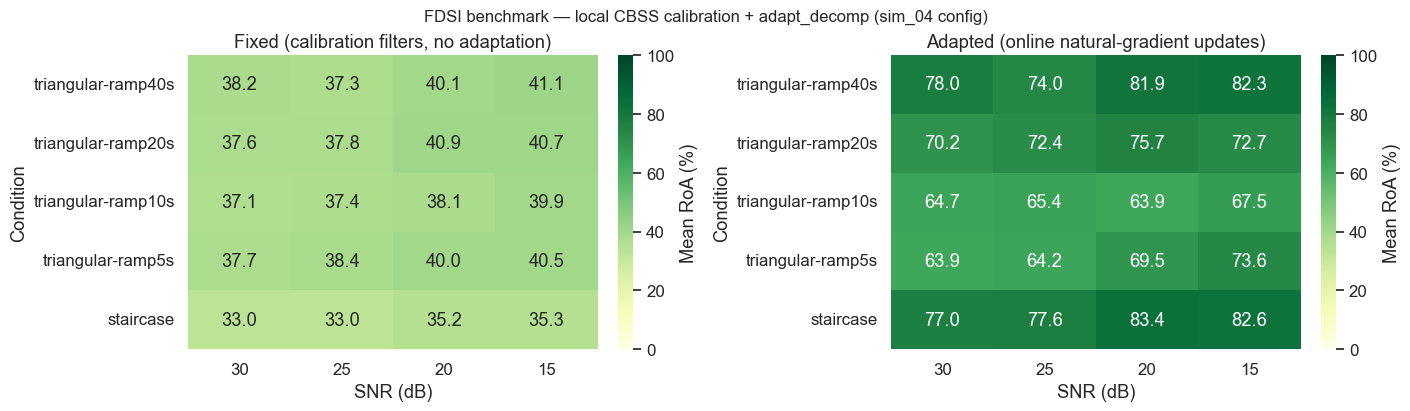

In [14]:
# Heatmaps: mean RoA per condition × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].mean().unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'Mean RoA (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

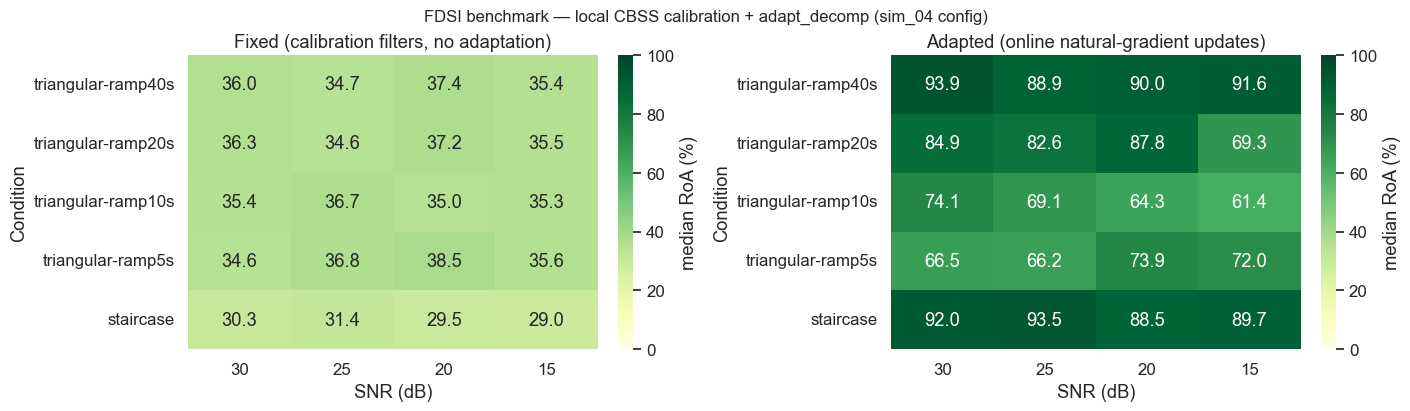

In [15]:
# Heatmaps: median RoA per condition × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].median().unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'median RoA (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

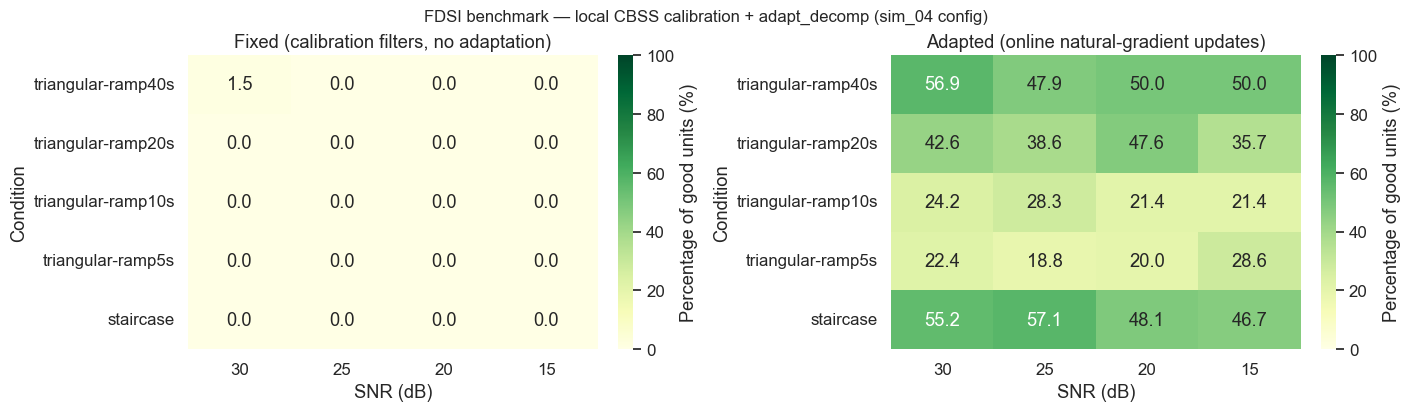

In [16]:
# Heatmaps: Percentage of good units (RoA >= 0.9) × SNR — fixed vs adapted side by side
fig, axs = plt.subplots(1, 2, figsize=(14, 4), layout='constrained')
for ax, col, title in [
    (axs[0], 'roa_fixed_pct',   'Fixed (calibration filters, no adaptation)'),
    (axs[1], 'roa_adapted_pct', 'Adapted (online natural-gradient updates)'),
]:
    pivot = df.groupby(['condition', 'snr'])[col].apply(lambda x: (x >= 90).sum() / len(x) * 100).unstack('snr')
    pivot = pivot.reindex(index=CONDITIONS, columns=SNR_LEVELS)
    sns.heatmap(
        pivot, annot=True, fmt='.1f', cmap='YlGn',
        vmin=0, vmax=100, ax=ax,
        cbar_kws={'label': 'Percentage of good units (%)'},
    )
    ax.set(title=title, xlabel='SNR (dB)', ylabel='Condition')

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (sim_04 config)',
    fontsize=12,
)
plt.show()

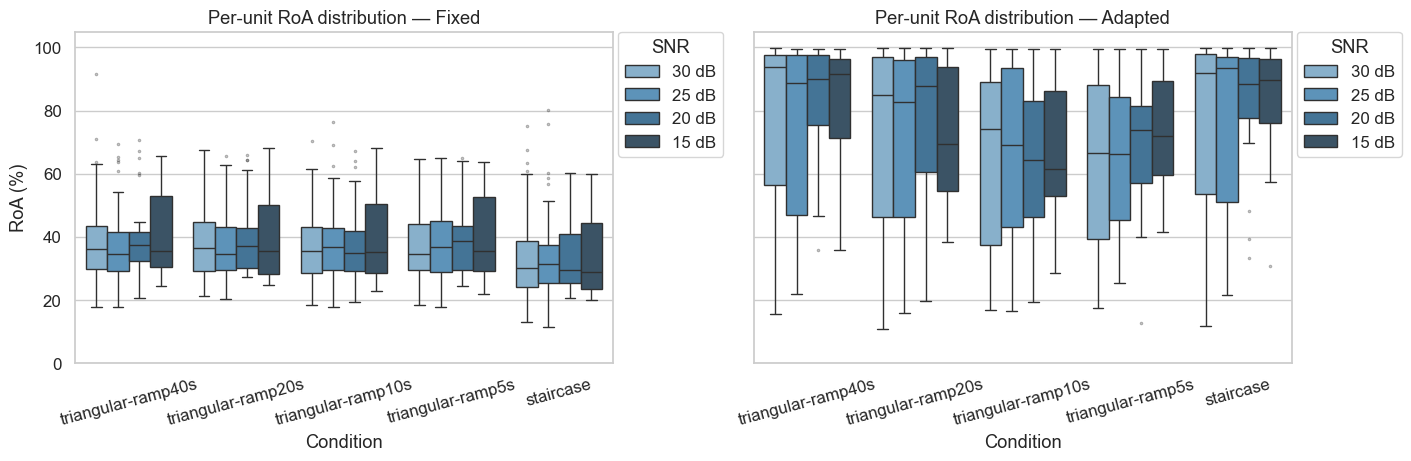

In [17]:
# Box plot: per-unit RoA distribution — fixed vs adapted, by condition and SNR
df_melt = df.melt(
    id_vars=['sub', 'condition', 'snr', 'unit'],
    value_vars=['roa_fixed_pct', 'roa_adapted_pct'],
    var_name='method', value_name='roa_pct',
)
df_melt['method'] = df_melt['method'].map({
    'roa_fixed_pct':   'Fixed',
    'roa_adapted_pct': 'Adapted',
})
df_melt['SNR'] = df_melt['snr'].astype(str) + ' dB'
snr_order = [f'{s} dB' for s in SNR_LEVELS]

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), layout='constrained', sharey=True)
for ax, method in zip(axs, ['Fixed', 'Adapted']):
    sub_df = df_melt[df_melt['method'] == method]
    sns.boxplot(
        data=sub_df, x='condition', y='roa_pct', hue='SNR',
        hue_order=snr_order, order=CONDITIONS,
        palette='Blues_d', flierprops=dict(marker='.', markersize=3, alpha=0.4),
        ax=ax,
    )
    ax.set(ylabel='RoA (%)', xlabel='Condition',
           title=f'Per-unit RoA distribution — {method}', ylim=(0, 105))
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='SNR', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

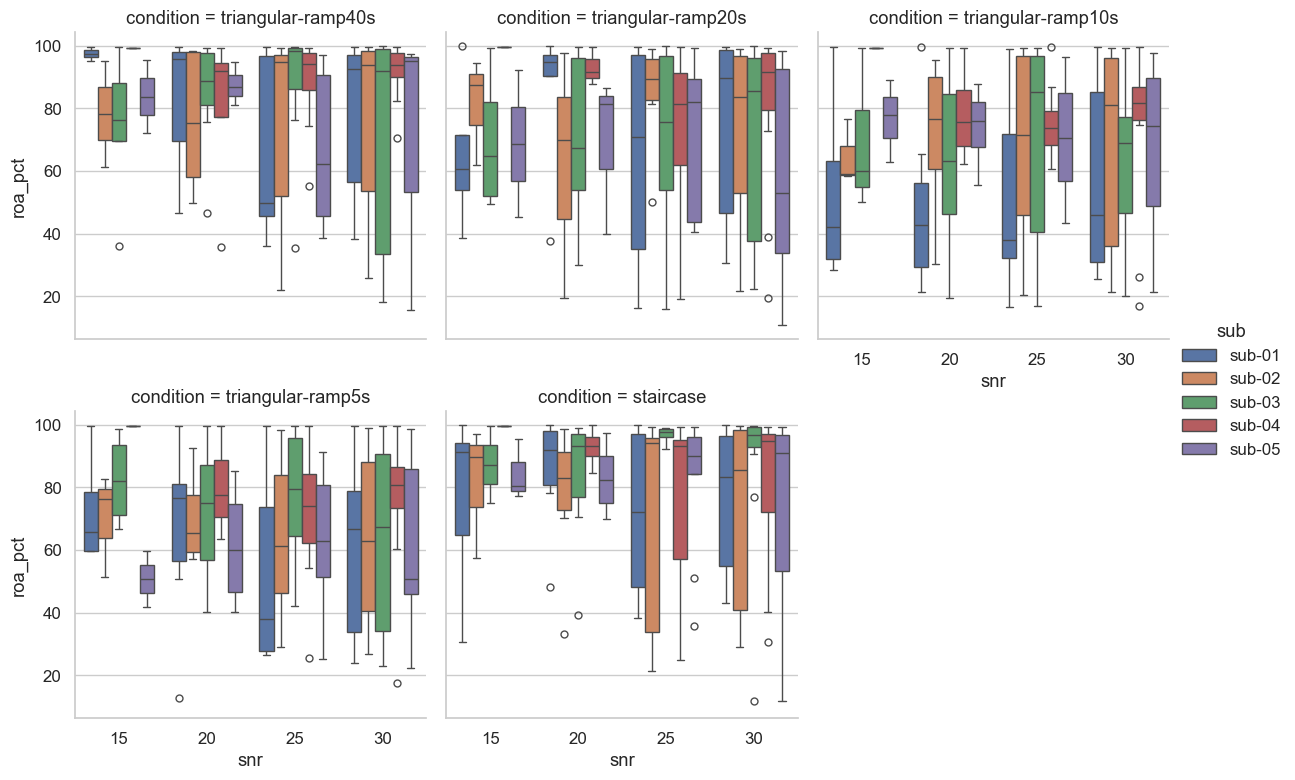

In [18]:
df_melt_adapt = df_melt[df_melt['method'] == 'Adapted']

g = sns.catplot(
    data=df_melt_adapt,
    x='snr', y='roa_pct', hue='sub',
    col = 'condition', col_wrap=3, sharey=True,
    kind="box", 
    margin_titles=True,
    height=4, aspect=1,
)

## 6. Phase RoA for triangular contractions

Three fixed-duration phases relative to the **full recording**:

| Phase | Samples | Duration |
|-------|---------|----------|
| **First isometric** | `[0, CAL_END)` | 5 s |
| **Triangular ramp** | `[CAL_END, n_full − ISO_DUR)` | recording-dependent |
| **Last isometric** | `[n_full − ISO_DUR, n_full)` | 5 s |

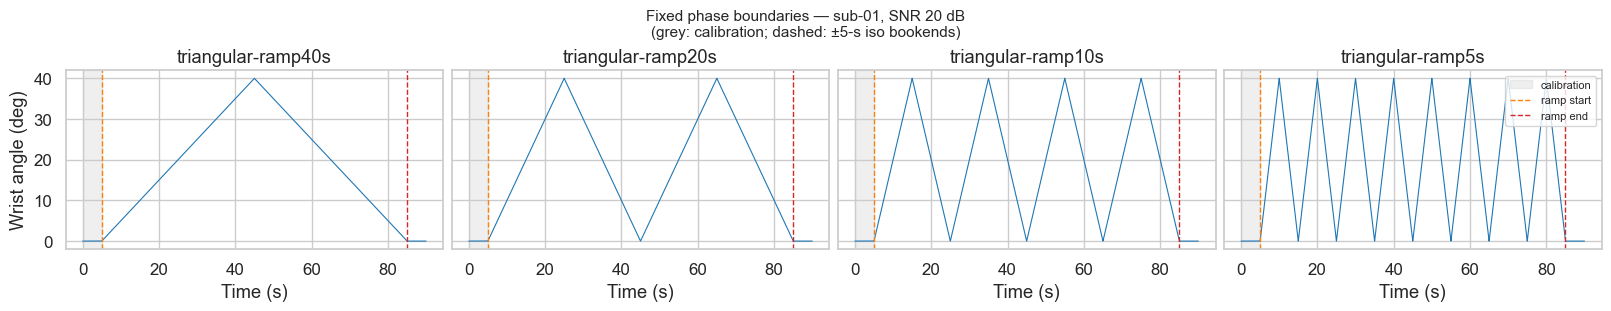

In [19]:
# Sanity check: full-recording angle profile with fixed phase boundaries
sub_check = 'sub-01'
snr_check = 20
n_tri     = len(TRIANGULAR)

fig, axs = plt.subplots(1, n_tri, figsize=(4 * n_tri, 3), layout='constrained', sharey=True)
for ax, cond in zip(axs, TRIANGULAR):
    key    = (sub_check, cond, snr_check)
    res    = results.get(key)
    if res is None:
        ax.set_title(f'{cond}\n[no data]')
        continue
    angle  = res['angle_full']
    n_full = res['n_full']
    t      = np.arange(n_full) / FS

    ramp_start_t = (CAL_END) / FS
    ramp_end_t   = (n_full - ISO_DUR) / FS

    ax.axvspan(0, CAL_END / FS, alpha=0.12, color='grey', zorder=0, label='calibration')
    ax.plot(t, angle, color='tab:blue', linewidth=0.8)
    ax.axvline(ramp_start_t, color='tab:orange', linestyle='--', linewidth=1, label='ramp start')
    ax.axvline(ramp_end_t,   color='tab:red',    linestyle='--', linewidth=1, label='ramp end')
    ax.set(title=cond, xlabel='Time (s)')

axs[0].set_ylabel('Wrist angle (deg)')
axs[-1].legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Fixed phase boundaries — {sub_check}, SNR {snr_check} dB\n'
    f'(grey: calibration; dashed: ±{ISO_DUR/FS:.0f}-s iso bookends)',
    fontsize=11,
)
plt.show()


In [20]:
PHASE_ORDER  = ['first_iso', 'ramp', 'last_iso']
PHASE_LABELS = {
    'first_iso': f'First iso\n(first {ISO_DUR//FS} s)',
    'ramp':      'Triangular ramp',
    'last_iso':  f'Last iso\n(last {ISO_DUR//FS} s)',
}

phase_rows = []
for (sub, cond, snr), res in results.items():
    if res is None or cond not in TRIANGULAR:
        continue
    for phase_name in PHASE_ORDER:
        roa_f = res['phase_roa'][phase_name]['fixed']
        roa_a = res['phase_roa'][phase_name]['adapted']
        for u, (rf, ra) in enumerate(zip(roa_f, roa_a)):
            phase_rows.append({
                'sub':         sub,
                'condition':   cond,
                'snr':         snr,
                'phase':       phase_name,
                'unit':        u,
                'roa_fixed':   float(rf),
                'roa_adapted': float(ra),
            })

df_phase = pd.DataFrame(phase_rows)
df_phase['roa_fixed_pct']   = df_phase['roa_fixed']   * 100
df_phase['roa_adapted_pct'] = df_phase['roa_adapted'] * 100
df_phase['phase'] = pd.Categorical(df_phase['phase'], categories=PHASE_ORDER, ordered=True)
print(f'Phase-RoA rows: {len(df_phase)}')


Phase-RoA rows: 1818


In [21]:
# Summary tables per triangular condition — fixed vs adapted per phase
for cond in TRIANGULAR:
    df_c = df_phase[df_phase['condition'] == cond]
    tbl  = (
        df_c.groupby(['snr', 'phase'], observed=True)[['roa_fixed_pct', 'roa_adapted_pct']]
        .mean().round(2)
        .unstack('phase')
    )
    tbl.columns = [f'{m.replace("roa_","").replace("_pct","")} ({p})' for m, p in tbl.columns]
    col_order = [f'{m} ({p})'
                 for p in PHASE_ORDER
                 for m in ['fixed', 'adapted']]
    tbl = tbl[[c for c in col_order if c in tbl.columns]]
    print(f'\n=== {cond} ===')
    print(tbl.to_string())
    print()


=== triangular-ramp40s ===
     fixed (first_iso)  adapted (first_iso)  fixed (ramp)  adapted (ramp)  fixed (last_iso)  adapted (last_iso)
snr                                                                                                            
15               94.18                97.09         30.54           80.60             92.79               87.59
20               95.06                96.91         29.08           80.72             95.26               80.77
25               95.70                97.37         25.98           71.77             95.64               83.77
30               97.29                98.26         26.85           75.90             97.42               88.59


=== triangular-ramp20s ===
     fixed (first_iso)  adapted (first_iso)  fixed (ramp)  adapted (ramp)  fixed (last_iso)  adapted (last_iso)
snr                                                                                                            
15               90.35                94.91    

In [ ]:
# Phase bar chart — fixed vs adapted, one row per method, one column per condition
n_tri = len(TRIANGULAR)
fig, axs = plt.subplots(2, n_tri, figsize=(5 * n_tri, 8),
                         layout='constrained', sharey=True)

for row, (method_col, method_label) in enumerate([
    ('roa_fixed_pct',   'Fixed'),
    ('roa_adapted_pct', 'Adapted'),
]):
    for col, cond in enumerate(TRIANGULAR):
        ax     = axs[row, col]
        df_c = df_phase[df_phase['condition'] == cond].copy()
        df_c['SNR'] = df_c['snr'].astype(str) + ' dB'
        sns.barplot(
            data=df_c, x='phase', y=method_col, hue='SNR',
            hue_order=[f'{s} dB' for s in SNR_LEVELS], order=PHASE_ORDER,
            estimator='mean', errorbar='sd', capsize=0.1,
            palette='Blues_d', ax=ax,
        )
        ax.set(xlabel='', ylabel='Mean RoA (%)', title=f'{method_label} — {cond}', ylim=(0, 105))
        ax.set_xticks(range(len(PHASE_ORDER)))
        ax.set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                           rotation=20, ha='right', fontsize=9)
        if col != 0:
            ax.set_ylabel('')
            ax.get_legend().remove()

plt.suptitle(
    'Three-phase RoA for triangular contractions — fixed vs adapted\n'
    '(averaged across subjects and units)',
    fontsize=12,
)
plt.show()

## 7. Summary figure

Condition labels on the x-axis below are marked to distinguish `POOL_CONDITIONS` (used by the
search in §3) from `HOLDOUT_CONDITIONS` (never seen by the optimiser) -- the generalisation
check for the pooled `(lr_v, lr_b)`.

In [ ]:
colors_snr = {30: '#1a237e', 25: '#1565c0', 20: '#42a5f5', 15: '#b3e5fc'}

fig, axs = plt.subplots(2, 2, figsize=(15, 9), layout='constrained')

for row, (method_col, method_label) in enumerate([
    ('roa_fixed_pct',   'Fixed'),
    ('roa_adapted_pct', 'Adapted'),
]):
    # ── Left: overall mean RoA per condition, one line per SNR ─────────────
    stats_by = df.groupby(['condition', 'snr'])[method_col].agg(['mean', 'std']).reset_index()
    for snr in SNR_LEVELS:
        sub_df = stats_by[stats_by['snr'] == snr].set_index('condition').reindex(CONDITIONS)
        axs[row, 0].errorbar(
            CONDITIONS, sub_df['mean'], yerr=sub_df['std'],
            marker='o', capsize=3, label=f'{snr} dB', color=colors_snr[snr],
        )
    axs[row, 0].set(
        ylabel='Mean RoA (%)',
        title=f'Overall RoA — {method_label}',
        ylim=(0, 105), xlabel='Condition',
    )
    axs[row, 0].set_xticks(range(len(CONDITIONS)))
    axs[row, 0].set_xticklabels(
        [f'{c}\n(held out)' if c in HOLDOUT_CONDITIONS else c for c in CONDITIONS],
        rotation=20, ha='right',
    )
    for tick_label, cond in zip(axs[row, 0].get_xticklabels(), CONDITIONS):
        if cond in HOLDOUT_CONDITIONS:
            tick_label.set_fontweight('bold')
            tick_label.set_color('firebrick')
    axs[row, 0].legend(title='SNR', fontsize=9)

    # ── Right: three-phase RoA averaged over all triangular conditions ────
    phase_df = df_phase.copy()
    phase_df['SNR'] = phase_df['snr'].astype(str) + ' dB'
    sns.barplot(
        data=phase_df, x='phase', y=method_col, hue='SNR',
        hue_order=[f'{s} dB' for s in SNR_LEVELS], order=PHASE_ORDER,
        estimator='mean', errorbar='sd', capsize=0.1,
        palette='Blues_d', ax=axs[row, 1],
    )
    axs[row, 1].set_xticks(range(len(PHASE_ORDER)))
    axs[row, 1].set_xticklabels([PHASE_LABELS[p] for p in PHASE_ORDER],
                                  rotation=20, ha='right')
    axs[row, 1].set(
        ylabel='Mean RoA (%)',
        title=f'Phase RoA (triangular) — {method_label}',
        ylim=(0, 105), xlabel='',
    )

plt.suptitle(
    'FDSI benchmark — local CBSS calibration + adapt_decomp (pooled-condition BO config)\n'
    'Fixed (frozen calibration filters) vs Adapted (online updates)',
    fontsize=12,
)
plt.show()